### Load Dataset

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Check for missing values across the dataset

In [56]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Clean Data: Handle missing values

In [57]:
df['Age'] = df['Age'].fillna(df['Age'].median())

most_common_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_port)

df = df.drop('Cabin', axis=1)

print("Missing values after all cleaning steps:")
print(df.isnull().sum())

Missing values after all cleaning steps:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Analysis Question 1: Who survived more, males or females?

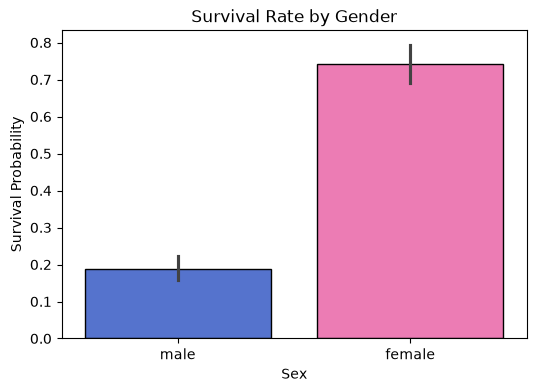

In [58]:
#Survival Rate by Gender
plt.figure(figsize=(6, 4))

custom_colors = {"male": "royalblue", "female": "hotpink"}
sns.barplot(x="Sex", y="Survived", hue="Sex", data=df, palette=custom_colors ,
             edgecolor="black")

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.savefig("survival_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** The data clearly shows that females had a much higher survival probability (around 74%) compared to males (around 19%). This stark contrast indicates that a "women and children first" protocol was likely followed during the evacuation of the Titanic.

### Analysis Question 2: Did passenger class affect survival chances?

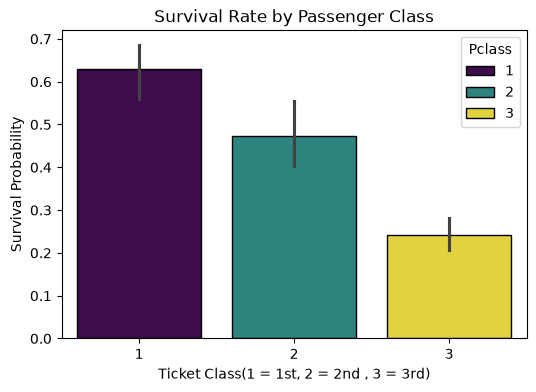

In [59]:
# Survival rate by passenger class
plt.figure(figsize=(6,4))

sns.barplot(x="Pclass", y="Survived", hue="Pclass",data=df,palette="viridis" ,
             edgecolor="black")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Ticket Class(1 = 1st, 2 = 2nd , 3 = 3rd)")
plt.ylabel("Survival Probability")
plt.savefig("Survival_by_class.png", dpi=300, bbox_inches="tight")
plt.show()


**Insight:** Passenger class heavily influenced survival chances. First-class (Pclass 1) passengers had the highest survival rate, while third-class (Pclass 3) passengers had the lowest. This suggests that higher-paying passengers had better access to lifeboats or were located on decks closer to the lifeboats during the evacuation.

### Analysis Question 3: What was the survival rate by age group?
Before calculating the survival rate, let's first look at the overall distribution of ages on the Titanic.

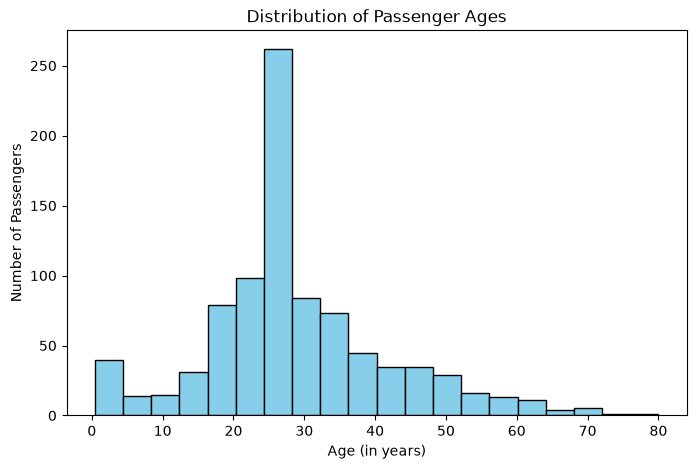

In [60]:
# Histogram of passenger ages
plt.figure(figsize=(8, 5))

df["Age"].plot(kind="hist", bins=20, color='skyblue', edgecolor='black')

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (in years)")
plt.ylabel("Number of Passengers")
plt.savefig("age_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** The histogram shows that the majority of passengers were young adults between the ages of 20 and 30. 
Now, let's group these ages into categories to see which demographic was most likely to survive.

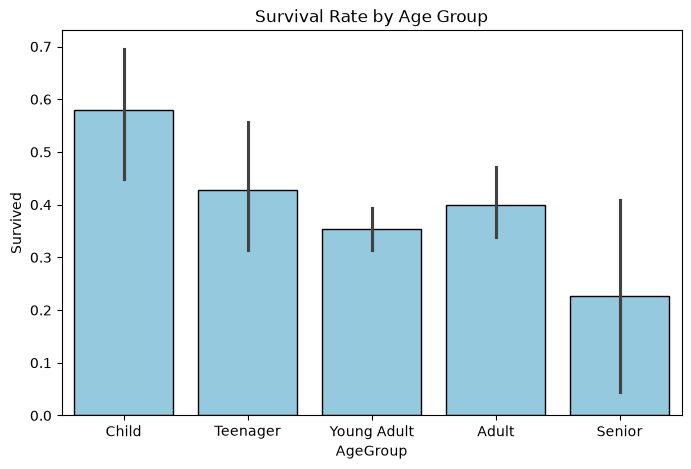

In [61]:
# Survival Rate by Age Group
plt.figure(figsize=(8, 5))

age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

sns.barplot(x="AgeGroup", y="Survived", data=df, color="skyblue", edgecolor="black")

plt.title("Survival Rate by Age Group")
plt.xlabel("AgeGroup")
plt.ylabel("Survived")
plt.savefig("survival_by_age_group_standard.png", dpi=300, bbox_inches="tight")
plt.show()

**Final Insight:** When breaking the passengers down by age group, children (ages 0-12) had the highest survival probability of any demographic. Adults and seniors had noticeably lower survival rates, further supporting the historical account that young children were prioritized during the rescue.